# ĐỒ ÁN KHAI PHÁ DỮ LIỆU
## Medical Appointment No Shows

### Sinh viên thực hiện
- Nguyễn Dương Bảo Trân - 3123410386
- Giang Hào Tường - 3123410421

### Bài toán
Dự đoán bệnh nhân có đến lịch hẹn khám bệnh hay không dựa trên các thuộc tính trong bộ dữ liệu.

### Hai câu hỏi khai phá dữ liệu
1. Những yếu tố nào ảnh hưởng nhiều nhất đến việc bệnh nhân không đến khám?
2. Có thể xây dựng mô hình dự đoán bệnh nhân no-show đủ tốt để hỗ trợ bệnh viện/phòng khám hay không?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Đã import xong thư viện.")

Đã import xong thư viện.


### 1. Đọc dữ liệu và xem thông tin tổng quan

In [17]:
file_path = "KaggleV2-May-2016.csv"
df = pd.read_csv(file_path)

print("Kích thước dữ liệu:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all").T)

Kích thước dữ liệu: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PatientId,110527.0,NaN,NaN,NaN,147496265710394.0625,256094920291739.09375,39217.84439,4172614444192.0,31731838713978.0,94391720898175.0,999981631772427.0
AppointmentID,110527.0,NaN,NaN,NaN,5675305.123427,71295.75154,5030230.0,5640285.5,5680573.0,5725523.5,5790484.0
Gender,110527,2,F,71840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScheduledDay,110527,103549,2016-05-06T07:09:54Z,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AppointmentDay,110527,27,2016-06-06T00:00:00Z,4692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,110527.0,NaN,NaN,NaN,37.088874,23.110205,-1.0,18.0,37.0,55.0,115.0
Neighbourhood,110527,81,JARDIM CAMBURI,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,110527.0,NaN,NaN,NaN,0.098266,0.297675,0.0,0.0,0.0,0.0,1.0
Hipertension,110527.0,NaN,NaN,NaN,0.197246,0.397921,0.0,0.0,0.0,0.0,1.0
Diabetes,110527.0,NaN,NaN,NaN,0.071865,0.258265,0.0,0.0,0.0,0.0,1.0


### 2. Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và phân bố biến mục tiêu ban đầu

In [18]:
missing = df.isnull().sum()
print("Các cột có giá trị thiếu:")
display(missing[missing > 0])

duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Kích thước dữ liệu sau khi xóa trùng:", df.shape)

print("Phân bố biến No-show:")
display(df["No-show"].value_counts())
display((df["No-show"].value_counts(normalize=True) * 100).round(2))

Các cột có giá trị thiếu:


Series([], dtype: int64)

Số dòng trùng lặp: 0
Phân bố biến No-show:


No     88208
Yes    22319
Name: No-show, dtype: int64

No     79.81
Yes    20.19
Name: No-show, dtype: float64

### 3. Tiền xử lý dữ liệu: chuẩn hóa tên cột và chuyển kiểu dữ liệu ngày tháng

In [5]:
data = df.copy()

data.columns = [col.strip().lower().replace("-", "_").replace(" ", "_") for col in data.columns]

data["scheduledday"] = pd.to_datetime(data["scheduledday"])
data["appointmentday"] = pd.to_datetime(data["appointmentday"])

print("Tên cột sau khi chuẩn hóa:")
print(data.columns.tolist())

display(data.head())
display(data[["scheduledday", "appointmentday"]].dtypes)

Tên cột sau khi chuẩn hóa:
['patientid', 'appointmentid', 'gender', 'scheduledday', 'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show']


,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


scheduledday      datetime64[ns, UTC]
appointmentday    datetime64[ns, UTC]
dtype: object

### 4. Tạo thuộc tính mới và xử lý các giá trị bất thường

In [19]:
data["waiting_days"] = (data["appointmentday"].dt.date - data["scheduledday"].dt.date).dt.days
data["scheduled_weekday"] = data["scheduledday"].dt.day_name()
data["appointment_weekday"] = data["appointmentday"].dt.day_name()
data["scheduled_hour"] = data["scheduledday"].dt.hour

print("Số tuổi âm:", (data["age"] < 0).sum())
print("Số waiting_days âm:", (data["waiting_days"] < 0).sum())

data = data[(data["age"] >= 0) & (data["waiting_days"] >= 0)].copy()

data["target"] = data["no_show"].map({"Yes": 1, "No": 0})

print("Kích thước dữ liệu sau khi làm sạch:", data.shape)
display(data[["age", "waiting_days", "target"]].head())

Số tuổi âm: 0
Số waiting_days âm: 0
Kích thước dữ liệu sau khi làm sạch: (110521, 19)


,age,waiting_days,target
0,62,0,0
1,56,0,0
2,62,0,0
3,8,0,0
4,56,0,0


### 5. Loại bỏ các cột không cần thiết cho mô hình

In [7]:
drop_cols = ["patientid", "appointmentid", "no_show"]
data_model = data.drop(columns=drop_cols)

print("Kích thước dữ liệu sau khi loại bỏ cột:", data_model.shape)
display(data_model.head())

Kích thước dữ liệu sau khi loại bỏ cột: (110521, 16)


,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,waiting_days,scheduled_weekday,appointment_weekday,scheduled_hour,target
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,Friday,Friday,18,0
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,Friday,Friday,16,0
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,Friday,Friday,16,0
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,Friday,Friday,17,0
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,Friday,Friday,16,0


### 6. Thống kê mô tả sau tiền xử lý

In [8]:
display(data_model.describe().T)

print("Tỷ lệ no-show:")
display(data["target"].value_counts(normalize=True) * 100)

,count,mean,std,min,25%,50%,75%,max
age,110521.0,37.089386,23.109885,0.0,18.0,37.0,55.0,115.0
scholarship,110521.0,0.098271,0.297682,0.0,0.0,0.0,0.0,1.0
hipertension,110521.0,0.197257,0.397929,0.0,0.0,0.0,0.0,1.0
diabetes,110521.0,0.071869,0.258272,0.0,0.0,0.0,0.0,1.0
alcoholism,110521.0,0.030401,0.171690,0.0,0.0,0.0,0.0,1.0
handcap,110521.0,0.022231,0.161494,0.0,0.0,0.0,0.0,4.0
sms_received,110521.0,0.321043,0.466879,0.0,0.0,0.0,1.0,1.0
waiting_days,110521.0,10.184345,15.255153,0.0,0.0,4.0,15.0,179.0
scheduled_hour,110521.0,10.774522,3.216204,6.0,8.0,10.0,13.0,21.0
target,110521.0,0.201898,0.401419,0.0,0.0,0.0,0.0,1.0


Tỷ lệ no-show:


0    79.810172
1    20.189828
Name: target, dtype: float64

### 7. Phân tích đơn biến

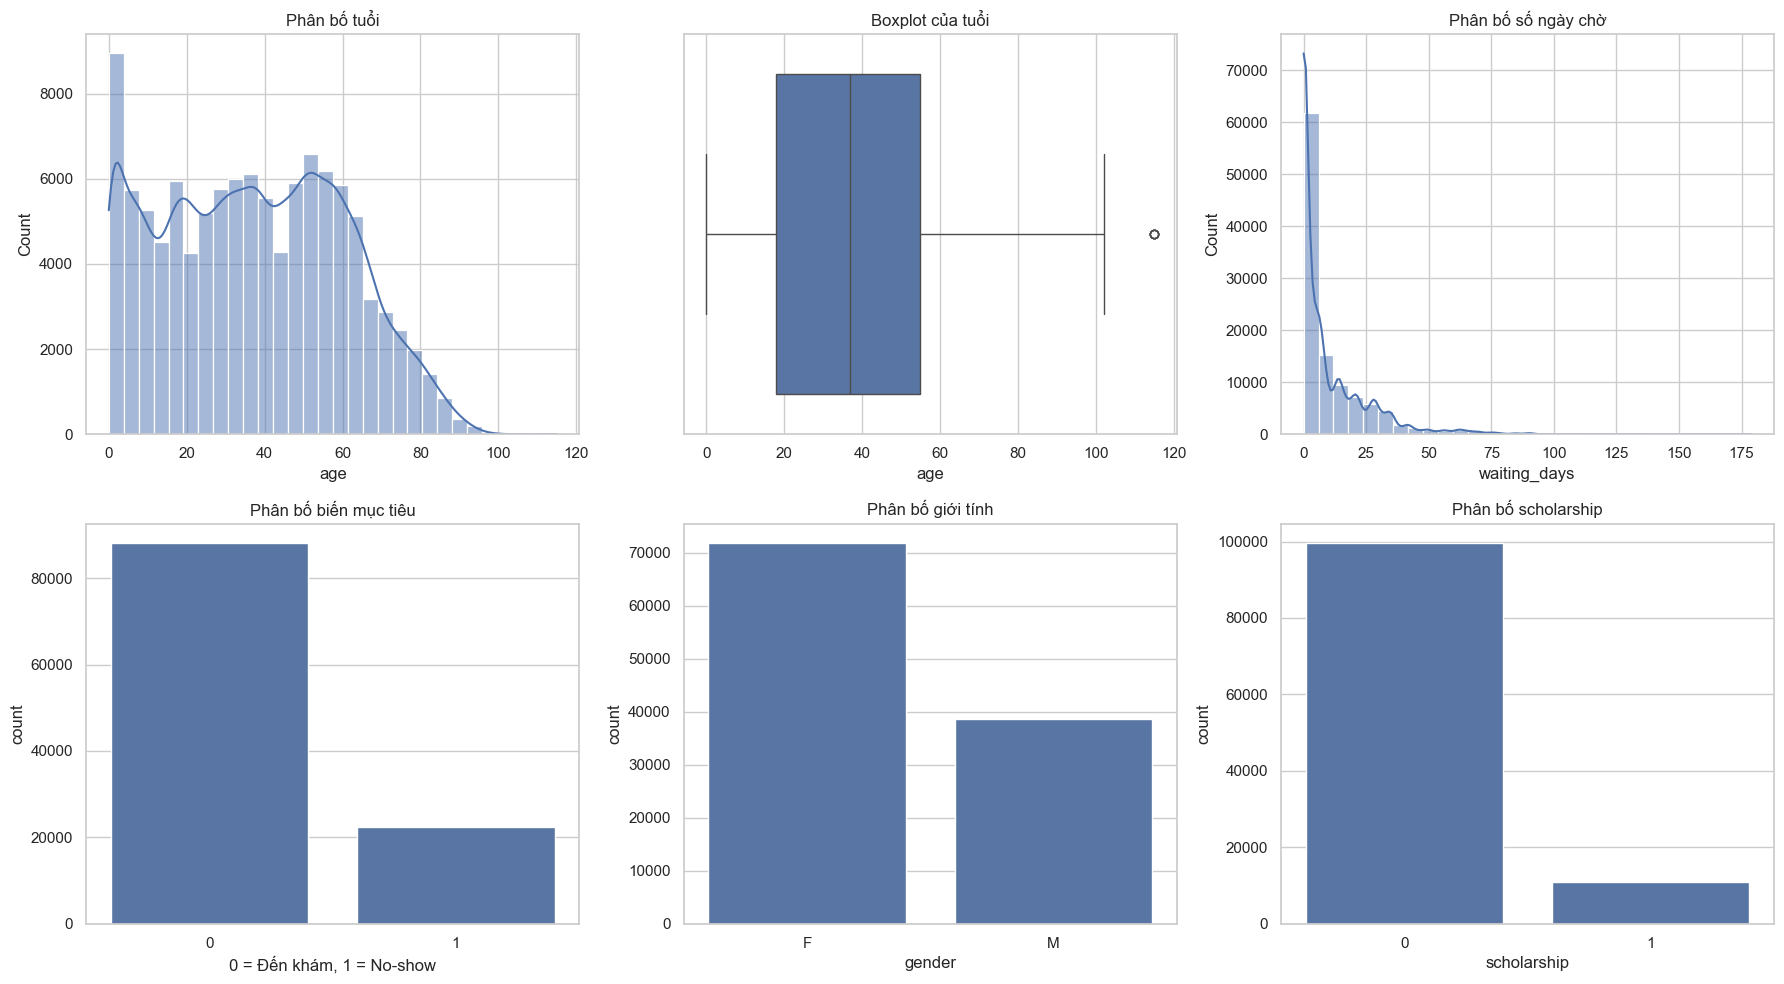

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(data["age"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Phân bố tuổi")

sns.boxplot(x=data["age"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot của tuổi")

sns.histplot(data["waiting_days"], bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Phân bố số ngày chờ")

sns.countplot(x="target", data=data, ax=axes[1, 0])
axes[1, 0].set_title("Phân bố biến mục tiêu")
axes[1, 0].set_xlabel("0 = Đến khám, 1 = No-show")

sns.countplot(x="gender", data=data, ax=axes[1, 1])
axes[1, 1].set_title("Phân bố giới tính")

sns.countplot(x="scholarship", data=data, ax=axes[1, 2])
axes[1, 2].set_title("Phân bố scholarship")

plt.tight_layout()
plt.show()

### 8. Phân tích đa biến

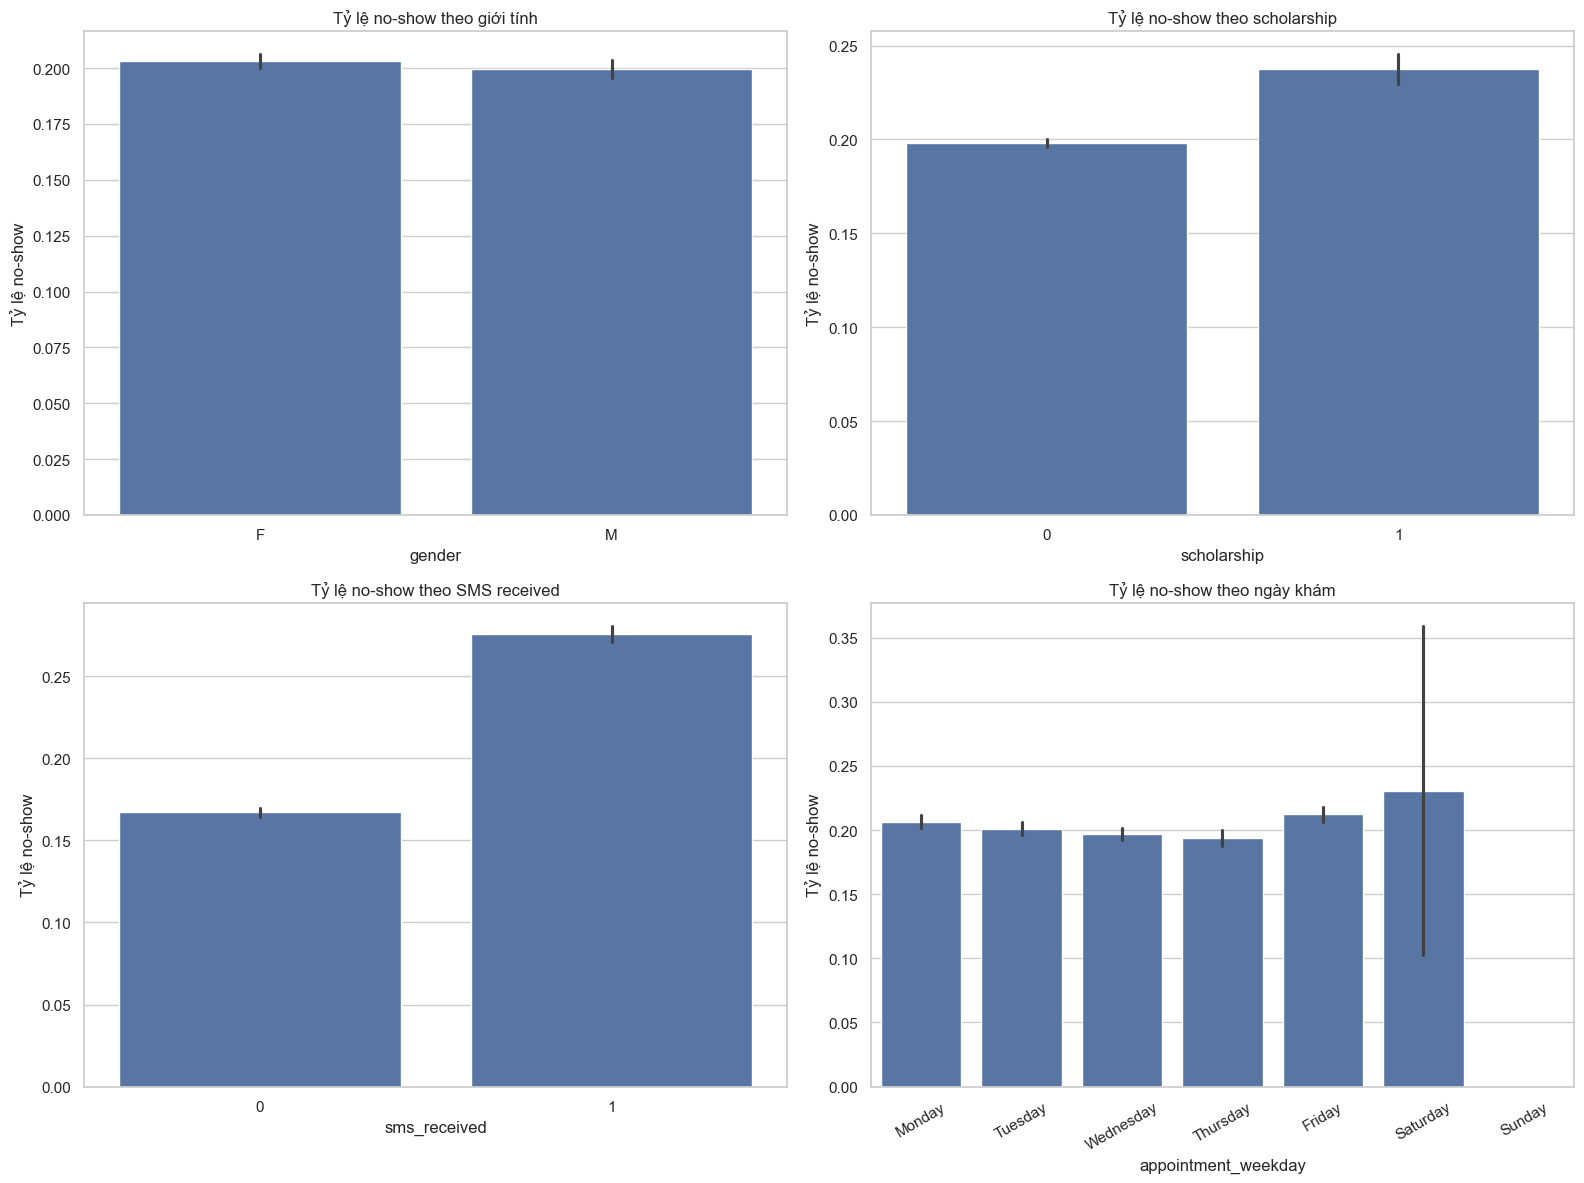

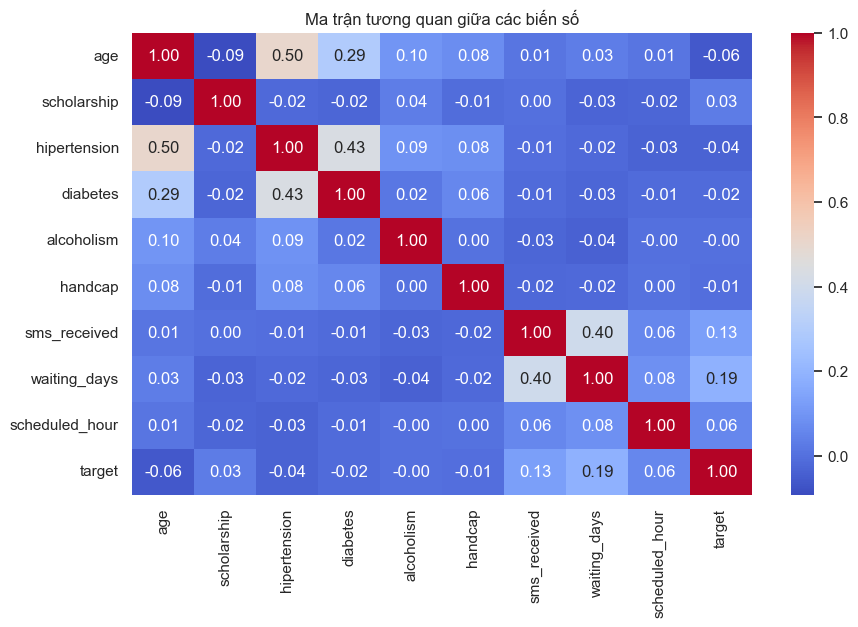

In [10]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(x="gender", y="target", data=data, ax=axes[0, 0])
axes[0, 0].set_title("Tỷ lệ no-show theo giới tính")
axes[0, 0].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="scholarship", y="target", data=data, ax=axes[0, 1])
axes[0, 1].set_title("Tỷ lệ no-show theo scholarship")
axes[0, 1].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="sms_received", y="target", data=data, ax=axes[1, 0])
axes[1, 0].set_title("Tỷ lệ no-show theo SMS received")
axes[1, 0].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="appointment_weekday", y="target", data=data, order=weekday_order, ax=axes[1, 1])
axes[1, 1].set_title("Tỷ lệ no-show theo ngày khám")
axes[1, 1].set_ylabel("Tỷ lệ no-show")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

numeric_cols = data_model.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 6))
sns.heatmap(data_model[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

### 9. Chuẩn bị dữ liệu cho mô hình

In [11]:
X = data_model.drop(columns=["target", "scheduledday", "appointmentday"])
y = data_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

Kích thước X_train: (88416, 13)
Kích thước X_test : (22105, 13)
Biến số: ['age', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'waiting_days', 'scheduled_hour']
Biến phân loại: ['gender', 'neighbourhood', 'scheduled_weekday', 'appointment_weekday']


### 10. Khởi tạo các mô hình phân loại

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8)
}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = None
    
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    
    return pipe, y_pred, y_prob, result

print("Đã khởi tạo xong các mô hình.")

Đã khởi tạo xong các mô hình.


### 11. Huấn luyện và so sánh các mô hình

In [13]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, y_pred, y_prob, result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    trained_models[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.795838,0.377451,0.017253,0.032998,0.663991
1,Decision Tree,0.798236,0.578947,0.002465,0.004909,0.717415
2,Random Forest,0.798100,0.000000,0.000000,0.000000,0.717419


### 12. Chọn mô hình tốt nhất và đánh giá chi tiết

Mô hình tốt nhất: Logistic Regression

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17642
           1       0.38      0.02      0.03      4463

    accuracy                           0.80     22105
   macro avg       0.59      0.51      0.46     22105
weighted avg       0.71      0.80      0.71     22105



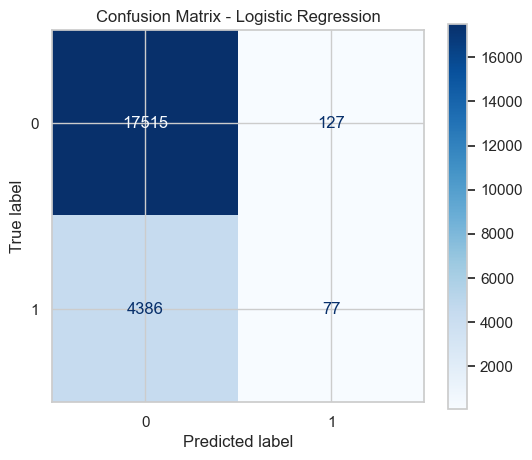

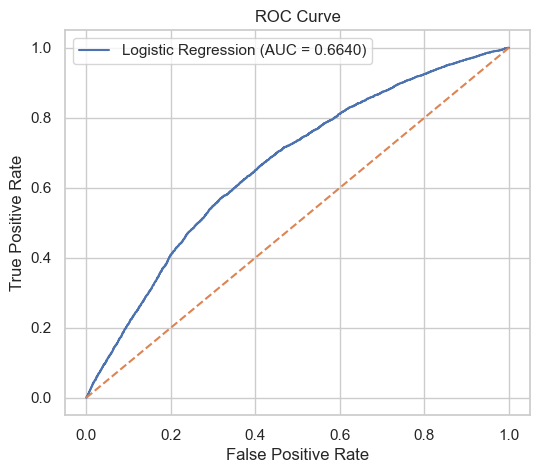

In [14]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]["pipeline"]
best_pred = trained_models[best_model_name]["y_pred"]
best_prob = trained_models[best_model_name]["y_prob"]

print("Mô hình tốt nhất:", best_model_name)
print()
print(classification_report(y_test, best_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

if best_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, best_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, best_prob):.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

### 13. Phân tích mức độ ảnh hưởng của các thuộc tính

,Feature,Coefficient
81,neighbourhood_SANTOS DUMONT,0.395798
10,gender_M,-0.390339
49,neighbourhood_JARDIM CAMBURI,-0.382607
7,waiting_days,0.370179
9,gender_F,-0.360416
63,neighbourhood_PARQUE MOSCOSO,0.354816
53,neighbourhood_JUCUTUQUARA,-0.337160
47,neighbourhood_ITARARÉ,0.334545
84,neighbourhood_SOLON BORGES,-0.333939
28,neighbourhood_DO CABRAL,-0.313290


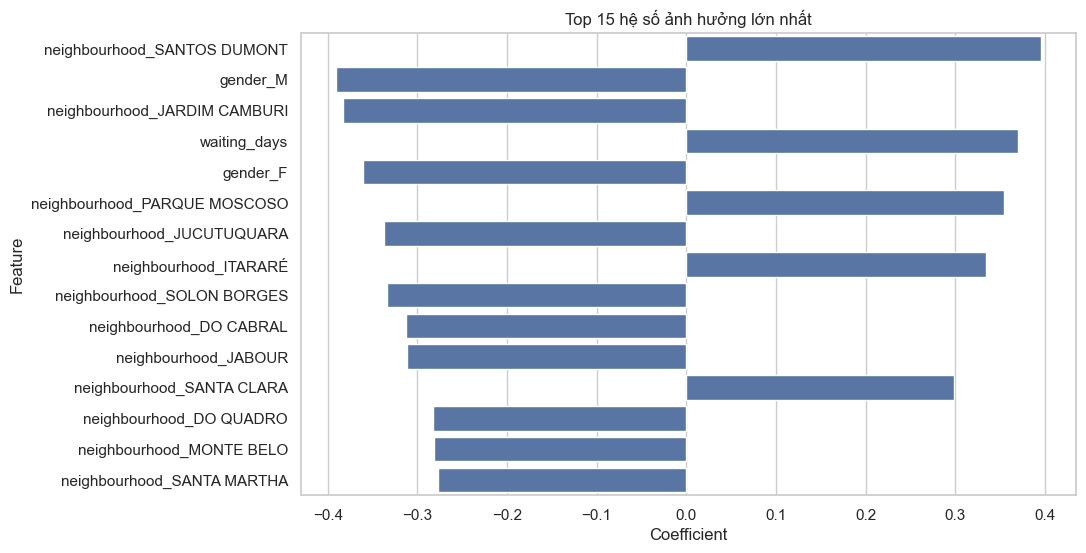

In [15]:
if best_model_name == "Random Forest":
    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)

    importances = best_model.named_steps["classifier"].feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(feat_imp.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
    plt.title("Top 15 thuộc tính quan trọng nhất")
    plt.show()

elif best_model_name == "Logistic Regression":
    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)

    coef = best_model.named_steps["classifier"].coef_[0]
    coef_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Coefficient": coef
    }).sort_values(by="Coefficient", key=np.abs, ascending=False)

    display(coef_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x="Coefficient", y="Feature")
    plt.title("Top 15 hệ số ảnh hưởng lớn nhất")
    plt.show()

else:
    print("Mô hình tốt nhất hiện tại không hỗ trợ trực tiếp việc hiển thị hệ số/feature importance theo cách này.")

### 14. Trả lời câu hỏi khai phá dữ liệu

**Câu hỏi 1: Những yếu tố nào ảnh hưởng nhiều nhất đến việc bệnh nhân không đến khám?**  
Dựa trên kết quả phân tích khám phá dữ liệu và mô hình học máy, hiện có thể nhận thấy một số nhóm yếu tố có khả năng ảnh hưởng đến việc bệnh nhân no-show như thời gian chờ giữa ngày đặt lịch và ngày khám, việc nhận tin nhắn nhắc lịch, độ tuổi và thời điểm khám.  
Tuy nhiên, để kết luận chính xác thuộc tính nào ảnh hưởng mạnh nhất, cần dựa thêm vào kết quả phân tích mức độ quan trọng của thuộc tính ở phần trên.

**Câu hỏi 2: Có thể xây dựng mô hình dự đoán bệnh nhân no-show đủ tốt để hỗ trợ bệnh viện/phòng khám hay không?**  
Dựa trên kết quả thực nghiệm, mô hình tốt nhất trong ba mô hình đã thử là **Logistic Regression** với các chỉ số:
- Accuracy = **0.795838**
- Precision = **0.377451**
- Recall = **0.017253**
- F1-score = **0.032998**
- ROC-AUC = **0.663991**

So với hai mô hình còn lại, Logistic Regression cho kết quả tốt hơn về **Accuracy**, **Recall** và **F1-score**. Tuy nhiên, giá trị **Recall** và **F1-score** vẫn rất thấp, cho thấy mô hình hiện tại chưa nhận diện tốt các trường hợp bệnh nhân no-show.  
Vì vậy, có thể kết luận rằng bài toán dự đoán bệnh nhân no-show là **có thể thực hiện được**, nhưng **mô hình hiện tại vẫn chưa đủ tốt để áp dụng hiệu quả trong thực tế**. Trong các bước tiếp theo, cần cải thiện mô hình bằng cách xử lý mất cân bằng dữ liệu, tối ưu siêu tham số hoặc thử thêm các thuật toán khác để nâng cao khả năng dự đoán.

In [20]:
results_df.to_csv("medical_model_comparison_results.csv", index=False)
print("Đã lưu file medical_model_comparison_results.csv")
results_df

Đã lưu file medical_model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.795838,0.377451,0.017253,0.032998,0.663991
1,Decision Tree,0.798236,0.578947,0.002465,0.004909,0.717415
2,Random Forest,0.798100,0.000000,0.000000,0.000000,0.717419


### 15. Kết luận tạm thời

Trong notebook này, bộ dữ liệu Medical Appointment No Shows đã được xử lý và phân tích để phục vụ bài toán phân loại.  
Các bước chính bao gồm:
- làm sạch dữ liệu,
- tạo thuộc tính mới,
- phân tích thống kê mô tả,
- phân tích đơn biến và đa biến,
- huấn luyện nhiều mô hình học máy,
- đánh giá và lựa chọn mô hình phù hợp.

Kết quả của notebook là cơ sở để tiếp tục hoàn thiện báo cáo cuối kỳ.